# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# importar librerías

In [4]:
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")
# cargar archivos

In [5]:
plans.head()
# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
users.head()
# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
usage.head()
# mostrar las primeras 5 filas de usage


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)
# revisar el número de filas y columnas de cada dataset

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
plans.info()
# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
users.info()
# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
usage.info()
# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
print(users.isna().sum())
# Cantidad de valores nulos
print(users.isna().mean())
# Proporción de valores nulos
# cantidad de nulos para users

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
print(usage.isna().sum())
print(usage.isna().mean())
# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- users("city") : Revisar registros y sustiruir nulos, 11.72 %, imputarlos.
- users("churn_date") : Confirmar que 88.35 % sean lineas activas, el resto indican ser lineas canceladas, 14% de usuarios, investigar.
- usage("date") : Estandarizar formato de fecha e imputar.
- usage("duration") : Parace complemento con columna "lenght", estandarizar e ignorar. Son llamadas?.
- usage("lenght") : Parece complemento columna "duration", estandarizar e ignorar. Son textos?.
- *** 28 valores ausentes (0.07%) resultado de : 40000-22076-17896. Investigar.
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
print(users[["age", "user_id"]].isna().sum())
users[["age","user_id"]].describe()
# explorar columnas numéricas de users

age        0
user_id    0
dtype: int64


,age,user_id
count,4000.000000,4000.000000
mean,33.739750,11999.500000
std,123.232257,1154.844867
min,-999.000000,10000.000000
25%,32.000000,10999.750000
50%,47.000000,11999.500000
75%,63.000000,12999.250000
max,79.000000,13999.000000


- La columna "user_id" : rangos percentiles homogeneos, cada 1000 "user_id" hay cambio.
- La columna "age" : sustiruir los registros con edad (-999) por el promedio.
- Ambas columnas SIN valores Nulos.

In [15]:
print(usage[["id", "user_id"]].isna().sum())
usage[["id", "user_id"]].describe()
# explorar columnas numéricas de usage

id         0
user_id    0
dtype: int64


,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas "id" y "user_id" : rangos percentiles homogeneos. muy similares, considerando 4000 registros de "user_id" y 40000 registros de "id".
- Ambas columnas SIN valores Nulos.

In [16]:
columnas_user = users[["city", "plan"]].isna().sum()
print(f"Cantidad de Nulos : {columnas_user}")
# explorar columnas categóricas de users

Cantidad de Nulos : city    469
plan      0
dtype: int64


- La columna "city" tiene 469 valores Nulos, imputarlos por "unknown"
- La columna "plan" NO tiene valores Nulos

In [17]:
column_usage = usage["type"].isna().sum()
print(f"Cantidad de Nulos : {column_usage}")
# explorar columna categórica de usage

Cantidad de Nulos : 0


- La columna "type" NO tiene valores Nulos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Valores invalidos en columna ("city").
- SIN valores invalidos en columnas users("plan") y usage("type").
- ¿Qué acción tomarías?
- Para columna users("city") sustituir valores Nulos por "unknown".
- Mantener columnas users("plan") y usage("type").

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")
reg_year_unique = users["reg_date"].dt.year.nunique()
print(f"Años de Registro : {reg_year_unique}")
reg_year_count = users["reg_date"].dt.year.value_counts()
print(f"Conteo por Año : {reg_year_count}")
# Convertir a fecha la columna `reg_date` de users

Años de Registro : 4
Conteo por Año : 2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


In [19]:
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")
reg_date_unique = usage["date"].dt.year.nunique()
print(f"Fechas unicas : {reg_date_unique}")
reg_date_count = usage["date"].dt.year.value_counts()
print(f"Conteo por Año : {reg_date_count}")
# Convertir a fecha la columna `date` de usage

Fechas unicas : 1
Conteo por Año : 2024.0    39950
Name: date, dtype: int64


In [20]:
users["reg_date"].describe()
# Revisar los años presentes en `reg_date` de users

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

En "reg_date", hay registros por 4 años, 2022, 2023, 2024 y 2026(40 registros). Detectarlos y decidir si Imputarlos o no.

In [21]:
usage["date"].describe()
# Revisar los años presentes en `date` de usage

count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

- En columna "date" los registros son de la 1ra mitad del año 2024, de los 40000 registros 50 NO son considerados en la revision. Detectarlos para decidir si Imputarlos o no.   
- Basaremos el análisis en estas fechas, 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
age_mediana = users["age"].median()
users["age"] = users["age"].replace(-999, age_mediana)
# Reemplazar -999 por la mediana de age

users['age'].describe()
# Verificar cambios

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
users["city"] = users["city"].replace("?", "NA")
# Reemplazar ? por NA en city

users["city"].value_counts()
# users["city"].describe()
# Verificar cambios

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [24]:
reg_date_2026 = users["reg_date"].dt.year == 2026
users.loc[reg_date_2026, "reg_date"] = pd.NaT
# Marcar fechas futuras como NA para reg_date

print(users["reg_date"].dt.year.value_counts())
# Verificar cambios

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
usage["duration"].isna().groupby(usage["type"]).sum()
# Verificación MAR en usage (Missing At Random) para duration

type
call        0
text    22076
Name: duration, dtype: int64

In [26]:
usage["length"].isna().groupby(usage["type"]).sum()
# Verificación MAR en usage (Missing At Random) para length

type
call    17896
text        0
Name: length, dtype: int64

- Nulos en "duration" corresponde a textos, No son MAR.
- Nulos en "length" corresponde a llamadas, NO son MAR.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
# Columnas auxiliares

usage_agg = usage.groupby("user_id").agg({
    "is_text" : "sum",
    "is_call" : "sum",
    "duration" : "sum"
}).reset_index()
# Agrupar información por usuario

usage_agg.head(3)
# observar resultado

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
usage_agg = usage_agg.rename(columns = {"is_text" : "cant_mensajes", "is_call" : "cant_llamadas", 
                                "duration" : "cant_minutos_llamada"})
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
user_profile = users.merge(usage_agg, on = "user_id", how = "left")
user_profile.head(5)
# Combinar la tabla agregada con el dataset de usuarios

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [30]:
users_no_use = user_profile["cant_mensajes"].isna().sum()
print(f"Usuarios sin registro de uso : {users_no_use}")
# Usuarios sin registro de uso

Usuarios sin registro de uso : 1


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
usage_agg[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()
# Resumen estadístico de las columnas numéricas

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [32]:
user_profile["plan"].value_counts(normalize = True) * 100
# Distribución porcentual del tipo de plan

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

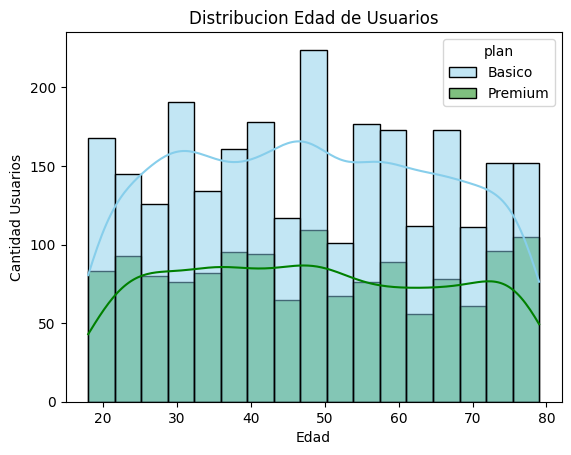

In [33]:
sns.histplot(data=user_profile, x="age", hue="plan", palette=["skyblue", "green"], kde=True)
plt.title("Distribucion Edad de Usuarios")
plt.xlabel("Edad")
plt.ylabel("Cantidad Usuarios")
plt.show()

# Histograma para visualizar la edad (age)

💡Insights: 
- Distribución uniforme para el plan Premium en la edad de los usuarios.
- Distribucion asimetrica con 2 excepciones en cantidad de usuarios para edades cercanas a los 30 y 50 años para el plan Basico.

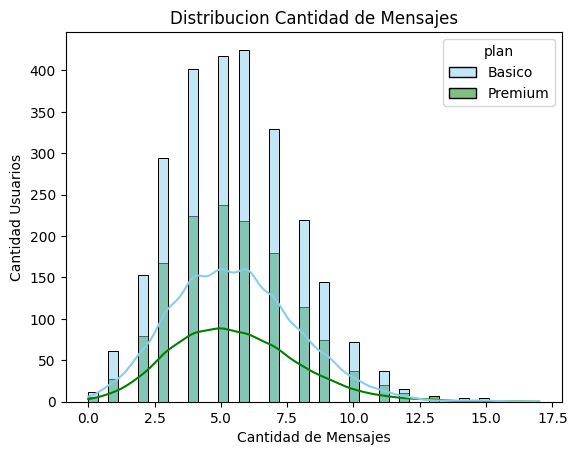

In [34]:
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=["skyblue", "green"], kde=True)
plt.title("Distribucion Cantidad de Mensajes")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad Usuarios")
plt.show()

# Histograma para visualizar la cant_mensajes

💡Insights: 
- Distribucion normal en cantidad de mensajes para usuarios del plan Premium.
- Distribucion normal, tambien, para usuarios del plan Basico.
- Ambas distribuciones presentan ligero sesgo a la derecha.
- Media y Mediana muy cercanas.

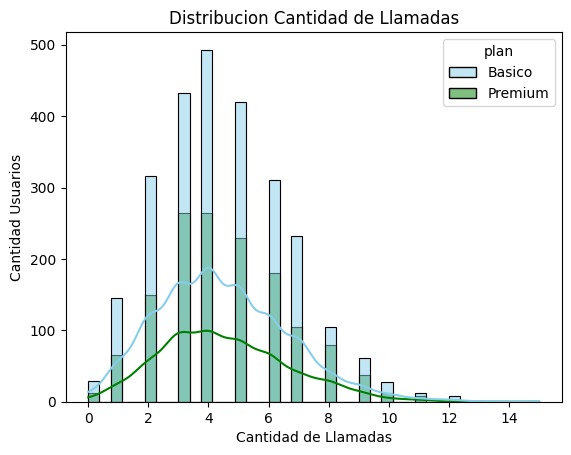

In [35]:
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=["skyblue", "green"], kde=True)
plt.title("Distribucion Cantidad de Llamadas")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Cantidad Usuarios")
plt.show()
# Histograma para visualizar la cant_llamadas

💡Insights: 
- Distribucion normal en cantidad de mensajes para usuarios del plan Premium. Ligero sesgo a la derecha.
- Distribucion normal, similar, para usuarios del plan Basico. Presenta tambien ligero sesgo a la derecha.
- Media y Mediana similares.

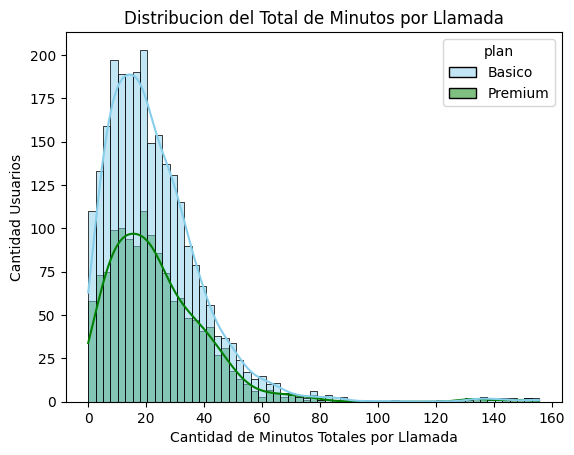

In [36]:
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=["skyblue", "green"], kde=True)
plt.title("Distribucion del Total de Minutos por Llamada")
plt.xlabel("Cantidad de Minutos Totales por Llamada")
plt.ylabel("Cantidad Usuarios")
plt.show()
# Histograma para visualizar la cant_minutos_llamada

💡Insights: 
- Distribucion con sesgo a la derecha para usuarios plna Premium.
- Distribucion con sesgo a la derecha para usuarios con plan Basico.
- Comportamiento similar para el total de minutos por llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

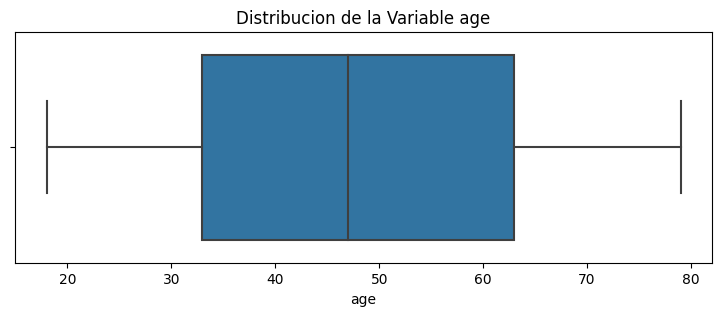

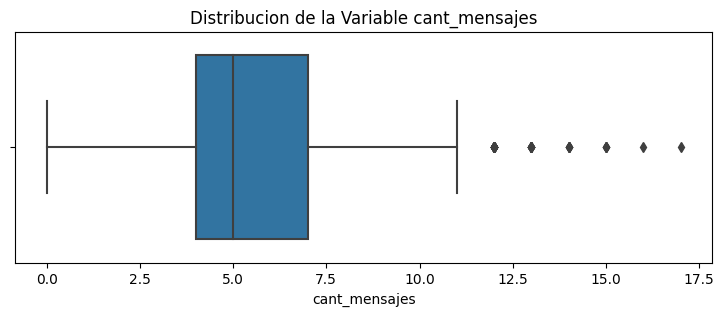

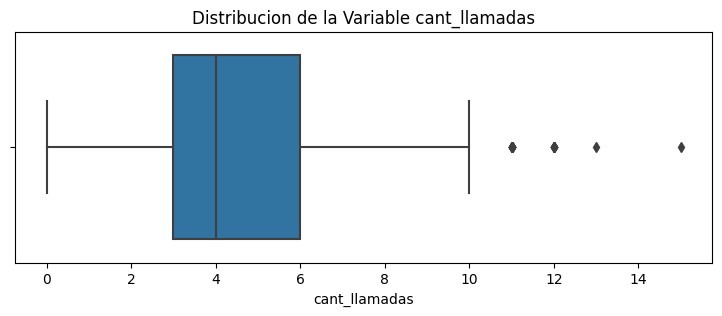

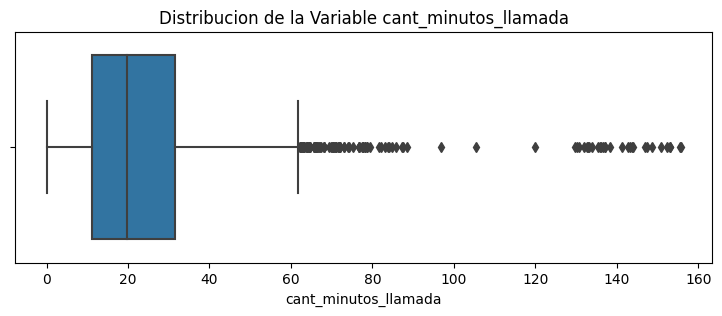

In [37]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9, 3))
    sns.boxplot(x=user_profile[col])
    plt.title(f"Distribucion de la Variable {col}")
    plt.show()
# Visualizando usando BoxPlot 

💡Insights: 
- Age: NO presenta outliers, distribucion simetrica.
- cant_mensajes: HAY outliers, distribucion orientada al limite superior.
- cant_llamadas: HAY outliers, distribucion orientada al limite superior.
- cant_minutos_llamada: Hay outliers (mayor cantidad, comparando con las columnas anteriores), distribucion orientada al limite inferior.

In [38]:
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"\n=== {col} ===")
    print(f"IQR : {IQR:.2f}")

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f"Limite inferior : {lower: .2f}")
    print(f"Limite superior : {upper: .2f}")

    outliers = (user_profile[(user_profile[col] > upper) | (user_profile[col] < lower)])
    print(f"Outliers encontrados : {len(outliers)}")

    if len(outliers) > 0:
        display(outliers[["user_id", "plan", col]].head())

# Calcular límites con el método IQR


=== cant_mensajes ===
IQR : 3.00
Limite inferior : -0.50
Limite superior :  11.50
Outliers encontrados : 46


,user_id,plan,cant_mensajes
315,10315,Basico,13.0
347,10347,Basico,13.0
356,10356,Basico,12.0
384,10384,Premium,12.0
456,10456,Basico,12.0



=== cant_llamadas ===
IQR : 3.00
Limite inferior : -1.50
Limite superior :  10.50
Outliers encontrados : 30


,user_id,plan,cant_llamadas
116,10116,Basico,11.0
417,10417,Basico,12.0
777,10777,Basico,12.0
778,10778,Basico,11.0
862,10862,Basico,15.0



=== cant_minutos_llamada ===
IQR : 20.30
Limite inferior : -19.32
Limite superior :  61.86
Outliers encontrados : 109


,user_id,plan,cant_minutos_llamada
27,10027,Premium,84.77
85,10085,Basico,152.36
93,10093,Basico,71.57
189,10189,Basico,155.42
198,10198,Basico,78.77


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener los outliers, considero casos extraordinarios de usuarios que utilizan el servicio de mensajes, 46 sobre 4000.
- cant_llamadas: Mantener los outliers, puede trartarse de usuarios cuya actividad es inusual, son minoria, para el servicio, 30 sobre 4000.
- cant_minutos_llamada: Mantener los outliers, 109 sobre 4000. Considerar comportamiento y constancia de usuarios, puede tratarse de un equipo de ventas, uso extraordinario de llamadas o accidentes, es decir, la linea queda abierta y no se finaliza la llamada.  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
def clasificar_grupo_uso(row):
    mensajes = row["cant_mensajes"]
    llamadas = row["cant_llamadas"]

    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Error en datos"
        # Verificar valore nulos

    if mensajes < 5 and llamadas < 5:
        return "Bajo Uso"
        
    elif mensajes < 10 and llamadas < 10:
        return "Uso Medio"
    
    else:
        return "Alto Uso"

user_profile["grupo_uso"] = user_profile.apply(clasificar_grupo_uso, axis=1)
# Crear columna grupo_uso

In [41]:
print(user_profile["grupo_uso"].value_counts())
user_profile[["cant_mensajes", "cant_llamadas", "grupo_uso"]].head(10)
# Verificar cambios

Uso Medio         2943
Bajo Uso           778
Alto Uso           278
Error en datos       1
Name: grupo_uso, dtype: int64


,cant_mensajes,cant_llamadas,grupo_uso
0,7.0,3.0,Uso Medio
1,5.0,10.0,Alto Uso
2,5.0,2.0,Uso Medio
3,11.0,3.0,Alto Uso
4,4.0,3.0,Bajo Uso
5,5.0,7.0,Uso Medio
6,3.0,5.0,Uso Medio
7,3.0,5.0,Uso Medio
8,5.0,5.0,Uso Medio
9,5.0,3.0,Uso Medio


In [42]:
user_profile.head()
# verificar cambios

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto Uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso Medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto Uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
def clasificar_grupo_edad(row):
    edad = row["age"]
    
    if pd.isna(edad):
        return "Error en datos"
        # Verificar valores nulos
        
    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"
        # Clasificar por edad

user_profile["grupo_edad"] = user_profile.apply(clasificar_grupo_edad, axis=1)
# Aplicar funcion
# Crear columna grupo_edad

In [44]:
print(user_profile["grupo_edad"].value_counts())
user_profile[["age", "grupo_edad"]].head(10)
# Verificar cambios

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor
5,61.0,Adulto Mayor
6,39.0,Adulto
7,70.0,Adulto Mayor
8,76.0,Adulto Mayor
9,47.0,Adulto


In [45]:
user_profile.head()
# verificar cambios

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

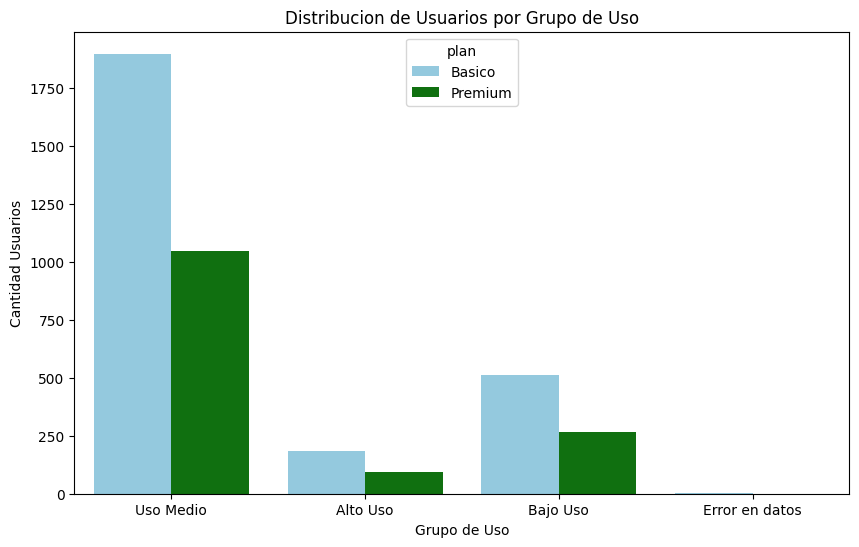

In [47]:
plt.figure(figsize=(10, 6))
sns.countplot(data=user_profile, x="grupo_uso", hue="plan", palette=["skyblue", "green"])
plt.title("Distribucion de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad Usuarios")
plt.show()
# Visualización de los segmentos por uso

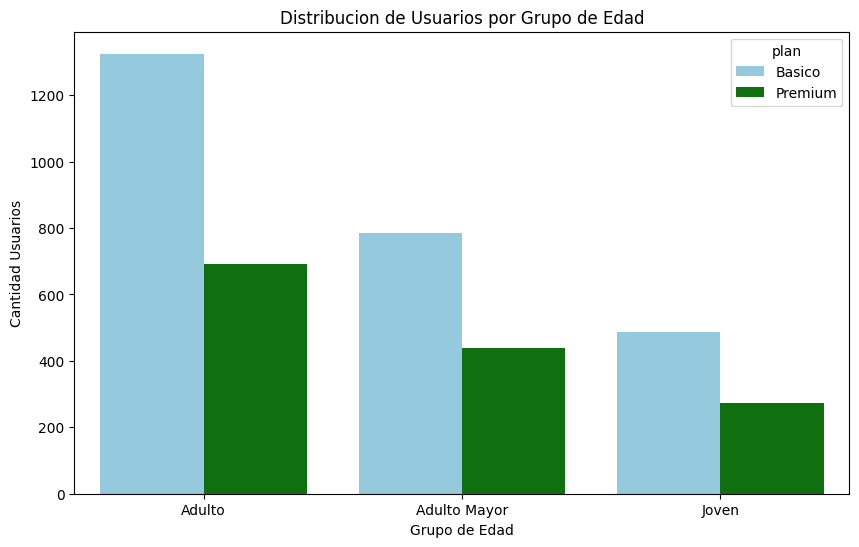

In [48]:
plt.figure(figsize=(10, 6))
sns.countplot(data=user_profile, x="grupo_edad", hue="plan", palette=["skyblue", "green"])
plt.title("Distribucion de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad Usuarios")
plt.show()
# Visualización de los segmentos por edad


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Investigar motivos por los servicios cancelados (churn_date), corresponden al 14% de los usuarios. Recuperarlos y/o cayeron en buro de credito.
- Las ciudades "unknown" pueden representar nicho de mercado o, se trata de usuarios privados, la linea permanece como "numero desconocido".
- Investigar con mas detalle a los usuarios de Alto Uso por el numero total de minutos en llamadas.


�� **Segmentos por Edad**
- El segmento de Adultos es el de mayor consumo para ambos planes de servicio.
- Sigue el segmento de Adulto Mayor en el consumo de ambos planes de servicio.
- Por ultimo, el segmento de Joven es el que menos consume ambos planes de servicio, es posible que la mayoria de usuarios en este grupo no esten incorporados en actividad laboral; circunstancia que restringe el uso de los servicios.
- En los 3 segmentos el plan Basico supera al plan Premium en numero de usuarios.


📊 **Segmentos por Nivel de Uso**
- El segmento de Uso Medio es el de mayor consumo para ambos planes de servicio.
- Sigue el segmento Bajo Uso en consumo para ambos planes de servicio.
- Por ultimo, el segmento de Alto Uso es el de menor consumo para ambos planes.
- En los 3 segmentos el plan Basico supera al plan Premium en numero de usuarios.


➡️ Esto sugiere que ...
- Los segmentos Adulto y Uso Medio son lideres en consumo de servicio. Poblacion economicamente activa.
- Ambos casos el plan Basico supera al plan Premium.


💡 **Recomendaciones**
- Sugiero investigar cuales usuarios en plan Basico pueden ser sujetos a escalar al plan Premium.
- Son la fuerza laboral activa, por posibilidades en credito, quienes son sujetos a escalar.
- Generar campañas de mercadeo para atraer mas usuarios jovenes a contratar servicios.
- Determinar numero de usuarios por ciudad y pais para determinar posibles nichos de mercado.
- Colombia tiene el 46% mientras Mexico el 39% del total de usuarios.
- Importante señalar que durante 2024 cancelaron servicios el 14% de usuarios. Investigar.
- La contratacion de lineas entre 2022 y 2024 (solo la 1ra mitad) fue similar por los 3 años, rondando el 32% - 33% por año.
- Si el crecimiento continua de la misma forma al final de 2024 estimariamos 2500 usuarios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`